# Phase 1: Exploratory Data Analysis (EDA)
### LogisChain AI - Cross-Domain Operational & Financial Risk Analytics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

features_df = pd.read_csv("../data/features/feature_matrix_50.csv")
port_df = pd.read_csv("../data/raw/port_throughput.csv")
edges_df = pd.read_csv("../data/raw/supply_chain_edges.csv")
print(f"Feature matrix loaded: {features_df.shape}")

Feature matrix loaded: (150, 51)


## 1. Supply Chain Network Topology Analysis

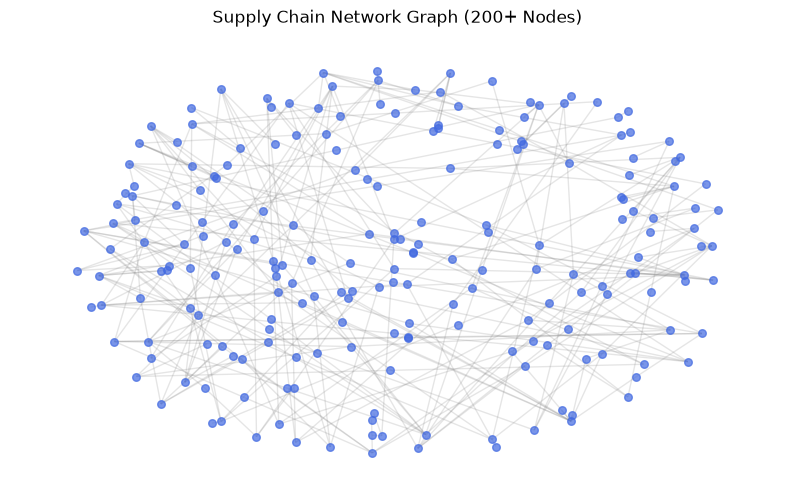

In [2]:
G = nx.from_pandas_edgelist(edges_df, source="source", target="target", edge_attr="flow_value_mil", create_using=nx.DiGraph())
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=30, node_color="royalblue", alpha=0.7)
nx.draw_networkx_edges(G, pos, alpha=0.2, edge_color="gray", arrows=False)
plt.title("Supply Chain Network Graph (200+ Nodes)")
plt.axis("off")
plt.show()

## 2. Port Congestion & Freight Dynamics

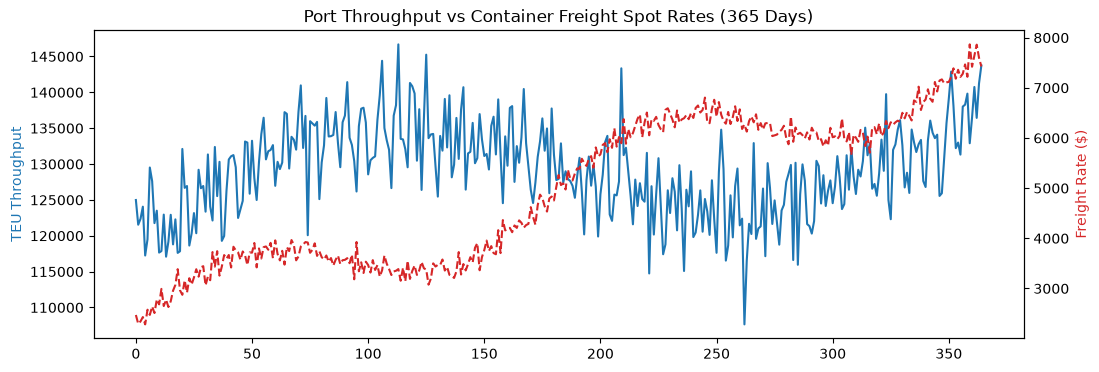

In [3]:
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(port_df.index, port_df["throughput_teu"], color="tab:blue", label="Throughput (TEU)")
ax1.set_ylabel("TEU Throughput", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(port_df.index, port_df["container_spot_rate"], color="tab:red", linestyle="--", label="Spot Freight Rate ($)")
ax2.set_ylabel("Freight Rate ($)", color="tab:red")
plt.title("Port Throughput vs Container Freight Spot Rates (365 Days)")
plt.show()

## 3. Operational vs Financial Distress Correlation

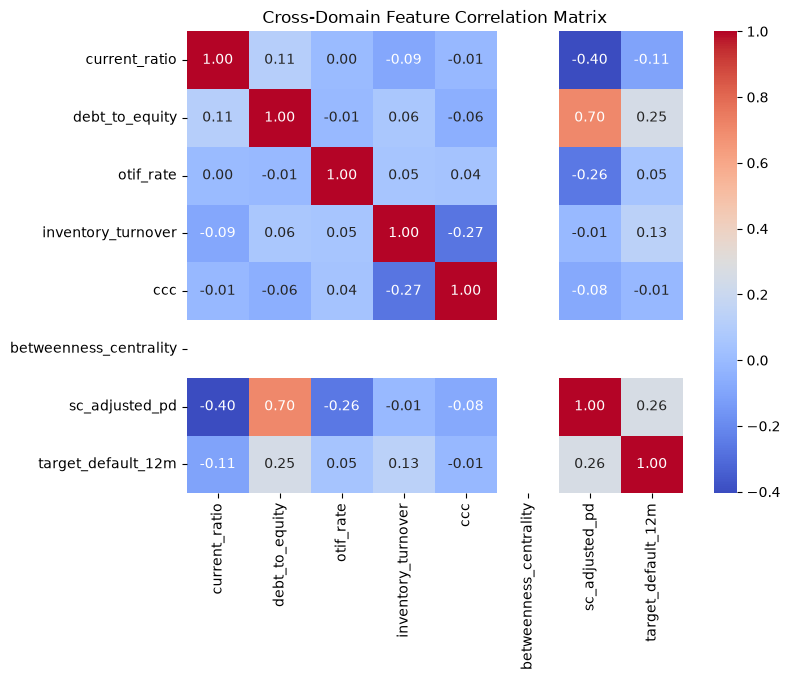

In [4]:
cols = ["current_ratio", "debt_to_equity", "otif_rate", "inventory_turnover", "ccc", "betweenness_centrality", "sc_adjusted_pd", "target_default_12m"]
corr = features_df[cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Cross-Domain Feature Correlation Matrix")
plt.show()